# Parts of Speech

## Exploring Changing Sentiment in Climate Articles: 2013 to 2023

#### This notebook builds F2 and F3 level models from the corpus.

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

## Imports

In [1]:
# General imports
import pandas as pd 
import numpy as np 
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Project-specific imports
import glob
from lxml import etree
from glob import glob
import re
import nltk
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)
        
        
# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [41]:
%%capture
%run notebooks/create_tables.ipynb

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### Compute Parts of Speech

In [5]:
VOCAB['n_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().unstack().count(1)
VOCAB['cat_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().to_frame('n').reset_index()\
    .groupby('term_str').pos_group.apply(lambda x: set(x))
VOCAB['n_pos'] = CORPUS[['term_str','pos']].value_counts().unstack().count(1)
VOCAB['cat_pos'] = CORPUS[['term_str','pos']].value_counts().to_frame('n').reset_index()\
    .groupby('term_str').pos.apply(lambda x: set(x))
VOCAB['max_pos'] = CORPUS[['term_str','pos']].value_counts().unstack(fill_value=0).idxmax(1)
VOCAB['max_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().unstack(fill_value=0).idxmax(1)

VOCAB.head()

n         p      p_yr  n_pos_group cat_pos_group  n_pos  \
year term_str                                                               
2013 the       3045  0.016252  0.063549            1          {DT}      1   
     of        1810  0.009661  0.037774            1          {IN}      1   
     and       1433  0.007649  0.029907            2      {NN, CC}      2   
     in        1206  0.006437  0.025169            2      {NN, IN}      2   
     to         967  0.005161  0.020181            1          {TO}      1   

                 cat_pos max_pos max_pos_group  
year term_str                                   
2013 the            {DT}      DT            DT  
     of             {IN}      IN            IN  
     and       {NNP, CC}      CC            CC  
     in        {NNP, IN}      IN            IN  
     to             {TO}      TO            TO

### Add POS Ambiguity

In [6]:
VOCAB['n_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().unstack().count(1)
VOCAB['cat_pos_group'] = CORPUS[['term_str','pos_group']].value_counts().to_frame('n').reset_index()\
    .groupby('term_str').pos_group.apply(lambda x: set(x))
VOCAB['n_pos'] = CORPUS[['term_str','pos']].value_counts().unstack().count(1)
VOCAB['cat_pos'] = CORPUS[['term_str','pos']].value_counts().to_frame('n').reset_index()\
    .groupby('term_str').pos.apply(lambda x: set(x))

### Reproduce finding about ambiguous words

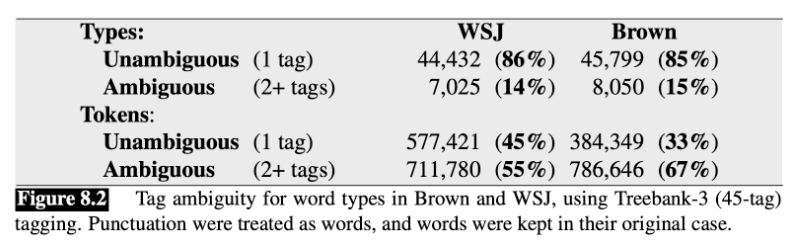

In [ ]:
# Group by number of parts of speech when greater than or equal to 2
# And aggregate by count and sum
Q = VOCAB.groupby(VOCAB.n_pos >= 2).agg({'n': ['count','sum']})
# Make into percentages
Q = ((Q / Q.sum()) * 100).round().astype(int)
# Find the (un)ambiguity for types and for tokens
Q.columns = ['climate corpus types', 'climate corpus tokens']
Q.index = ['unambiguous','ambiguous']
Q.style.background_gradient()

,climate corpus types,climate corpus tokens
unambiguous,69,51
ambiguous,31,49


In [39]:
# Add WSJ and Brown information
new_cols = ['wsj corpus types', 'wsj corpus tokens', 'brown corpus types', 'brown corpus tokens']
new = pd.DataFrame(columns = new_cols).astype('float')
Q_tot = pd.concat([Q, new])

# Ading WSJ types
Q_tot.loc['unambiguous', 'wsj corpus types'] = 86
Q_tot.loc['ambiguous', 'wsj corpus types'] = 14

# Adding WSJ tokens
Q_tot.loc['unambiguous', 'wsj corpus tokens'] = 45
Q_tot.loc['ambiguous', 'wsj corpus tokens'] = 55

# Repeat for Brown
Q_tot.loc['unambiguous', 'brown corpus types'] =85
Q_tot.loc['ambiguous', 'brown corpus types'] = 15
Q_tot.loc['unambiguous', 'brown corpus tokens'] = 33
Q_tot.loc['ambiguous', 'brown corpus tokens'] = 67

Q_tot.style.background_gradient()

,climate corpus types,climate corpus tokens,wsj corpus types,wsj corpus tokens,brown corpus types,brown corpus tokens
unambiguous,69.000000,51.000000,86.000000,45.000000,85.000000,33.000000
ambiguous,31.000000,49.000000,14.000000,55.000000,15.000000,67.000000


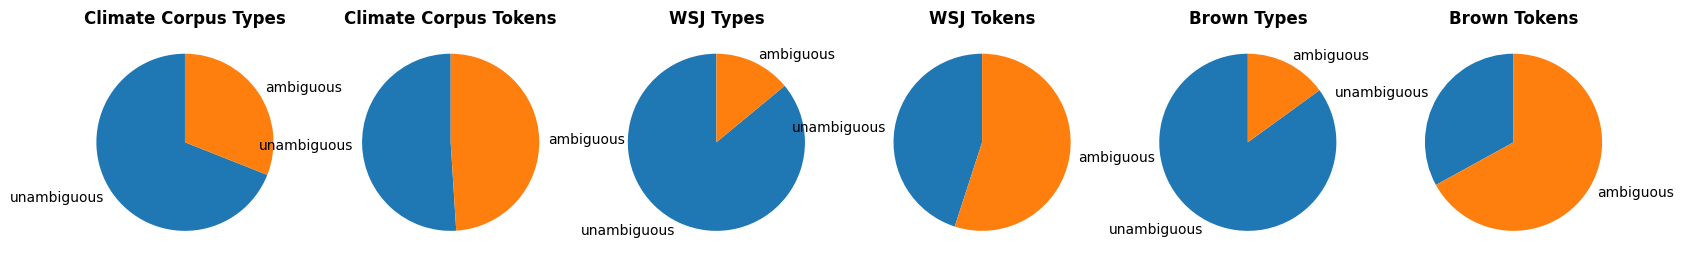

In [40]:
ax = Q_tot.plot.pie(subplots=True, legend=False, startangle=90, figsize=(20,8))
# No Y labels
ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[2].set_ylabel('')
ax[3].set_ylabel('')
ax[4].set_ylabel('')
ax[5].set_ylabel('')
# Plot climate corpus as well as WSJ and Brown findings
ax[0].set_title('Climate Corpus Types', fontweight='bold')
ax[1].set_title('Climate Corpus Tokens', fontweight='bold')
ax[2].set_title('WSJ Types', fontweight='bold')
ax[3].set_title('WSJ Tokens', fontweight='bold')
ax[4].set_title('Brown Types', fontweight='bold')
ax[5].set_title('Brown Tokens', fontweight='bold')
plt.show()

The climate corpus has more ambiguous types but fewer* ambiguous tokens as compared to WSJ and Brown. 

*I wonder if this is connected to the fact that this is scientific writing as opposed to more editorial style writing, which can sometimes be more flowery and ambiguous.

In [9]:
VOCAB.loc[(VOCAB.n_pos == 1) & (VOCAB.max_pos.str.match('(VB|NN)'))].sample(10)

n         p      p_yr  n_pos_group cat_pos_group  n_pos  \
year term_str                                                                 
2023 symportalorg   1  0.000005  0.000013            1          {NN}      1   
     songming       3  0.000016  0.000038            1          {NN}      1   
     tabulations    1  0.000005  0.000013            1          {NN}      1   
     arcsecond      1  0.000005  0.000013            1          {NN}      1   
2013 appeared       4  0.000021  0.000083            1          {VB}      1   
2018 surf7          1  0.000005  0.000017            1          {NN}      1   
2023 agreement     17  0.000091  0.000213            1          {NN}      1   
2013 conditioned    2  0.000011  0.000042            1          {VB}      1   
2018 alkalinity    16  0.000085  0.000269            1          {NN}      1   
2023 impede         1  0.000005  0.000013            1          {NN}      1   

                  cat_pos max_pos max_pos_group  
year term_str                                    
2023 symportalorg    {NN}      NN            NN  
     songming       {NNP}     NNP            NN  
     tabulations    {NNS}     NNS            NN  
     arcsecond       {NN}      NN            NN  
2013 appeared       {VBD}     VBD            VB  
2018 surf7          {NNP}     NNP            NN  
2023 agreement       {NN}      NN            NN  
2013 conditioned    {VBN}     VBN            VB  
2018 alkalinity      {NN}      NN            NN  
2023 impede          {NN}      NN            NN

In [ ]:
VOCAB.loc[(VOCAB.n_pos >= 2) & (VOCAB.max_pos.str.match('(VB|NN)'))].sample(10)

n         p      p_yr  n_pos_group cat_pos_group  n_pos  \
year term_str                                                               
2023 encouraged   2  0.000011  0.000025            1          {VB}      2   
2018 km2          8  0.000043  0.000135            1          {NN}      2   
     becomes      3  0.000016  0.000050            2      {NN, VB}      2   
2013 trimmed      2  0.000011  0.000042            1          {VB}      2   
     identity     5  0.000027  0.000104            1          {NN}      2   
     standardize  1  0.000005  0.000021            2      {NN, VB}      2   
2023 mentioned    6  0.000032  0.000075            1          {VB}      2   
     gaps         4  0.000021  0.000050            1          {NN}      2   
     compare      1  0.000005  0.000013            1          {VB}      2   
2013 beginning    5  0.000027  0.000104            2      {NN, VB}      2   

                     cat_pos max_pos max_pos_group  
year term_str                                       
2023 encouraged   {VBN, VBD}     VBN            VB  
2018 km2           {NNS, NN}     NNS            NN  
     becomes      {NNS, VBZ}     VBZ            VB  
2013 trimmed      {VBN, VBD}     VBN            VB  
     identity      {NN, NNP}      NN            NN  
     standardize    {NN, VB}      VB            VB  
2023 mentioned    {VBN, VBD}     VBN            VB  
     gaps          {NNS, NN}     NNS            NN  
     compare       {VBP, VB}      VB            VB  
2013 beginning     {NN, VBG}      NN            NN

### Saving to CSV

In [44]:
VOCAB.to_csv("csvs/VOCAB/VOCAB_pos.csv", index=False)